# A mechanism atlas for pointwise intrinsic GAD

## Four small experiments for four distinct design decisions

<div style="padding: 0.9em 1.1em; border-left: 5px solid #0072B2; background: #F3F8FB">
<b>Purpose.</b> The symmetric four-well surface is a useful overview, but it cannot honestly isolate every failure mechanism. This notebook uses a different minimal setup for each question: why GAD works locally, why high-index starts require descent, what gradient competition adds, and why relative soft-subspace reflection is needed near degeneracy.
</div>

The analytic panels explain mechanisms; the LJ7 and g-xTB panels report frozen benchmark evidence from [`POINTWISE_INTRINSIC_GAD.md`](../docs/POINTWISE_INTRINSIC_GAD.md). No toy panel is presented as a chemical benchmark.

## Reading the atlas

| Step | Local question | Isolating experiment |
|---|---|---|
| **1. Ordinary GAD** | Why reflect a mode? | Turn an index-one saddle into a local attractor. |
| **2. Descent-then-GAD** | Why suppress ascent at high index? | Expose the additional expanding modes, then compare with LJ7 recovery. |
| **3. Competitive GAD** | What does force activity add to $\lambda_2$? | Map the gate in curvature-activity space and inspect one local decision. |
| **4. CS²-GAD** | Why use $p_i/\max p$? | Show normalized-density cancellation in an isotropic soft basin and the paired g-xTB rescue. |

All method arrows below are raw local fields unless a panel explicitly says it shows the regularized closed-form step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, Patch

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.size': 10,
})

COLORS = {
    'descent': '#D55E00', 'ordinary': '#6F6F6F', 'hard': '#CC79A7',
    'lambda2': '#CC79A7', 'competitive': '#0072B2', 'subspace': '#009E73',
}
INDEX_CMAP = ListedColormap(['#EAF4EC', '#FFF3DD', '#F9E5EE'])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60.0, 60.0)))

def normalized_arrows(field, points, length=.10):
    vec = np.asarray([field(p) for p in points], dtype=float)
    norm = np.linalg.norm(vec, axis=1, keepdims=True)
    return length * vec / np.maximum(norm, 1e-12)

def euler_trace(start, field, dt, steps, stop_radius=None):
    path = [np.asarray(start, dtype=float)]
    for _ in range(steps):
        nxt = path[-1] + dt * field(path[-1])
        path.append(nxt)
        if stop_radius is not None and np.linalg.norm(nxt) > stop_radius:
            break
    return np.asarray(path)

def finish_plane(ax, lim, title):
    ax.set(xlim=lim, ylim=lim, aspect='equal', xlabel='$x$', ylabel='$y$', title=title)

# 1. Ordinary GAD makes an index-one saddle attractive

Consider

$$V_1(x,y)=(x^2-1)^2+\tfrac12y^2.$$

The origin is an index-one saddle with $H(0,0)=\operatorname{diag}(-4,1)$. Physical descent is repelled along $x$ and falls into either minimum. Ordinary GAD reflects the lowest-curvature component, so both local directions contract toward the saddle. This is the setting in which one-mode GAD is exactly the right local dynamics.

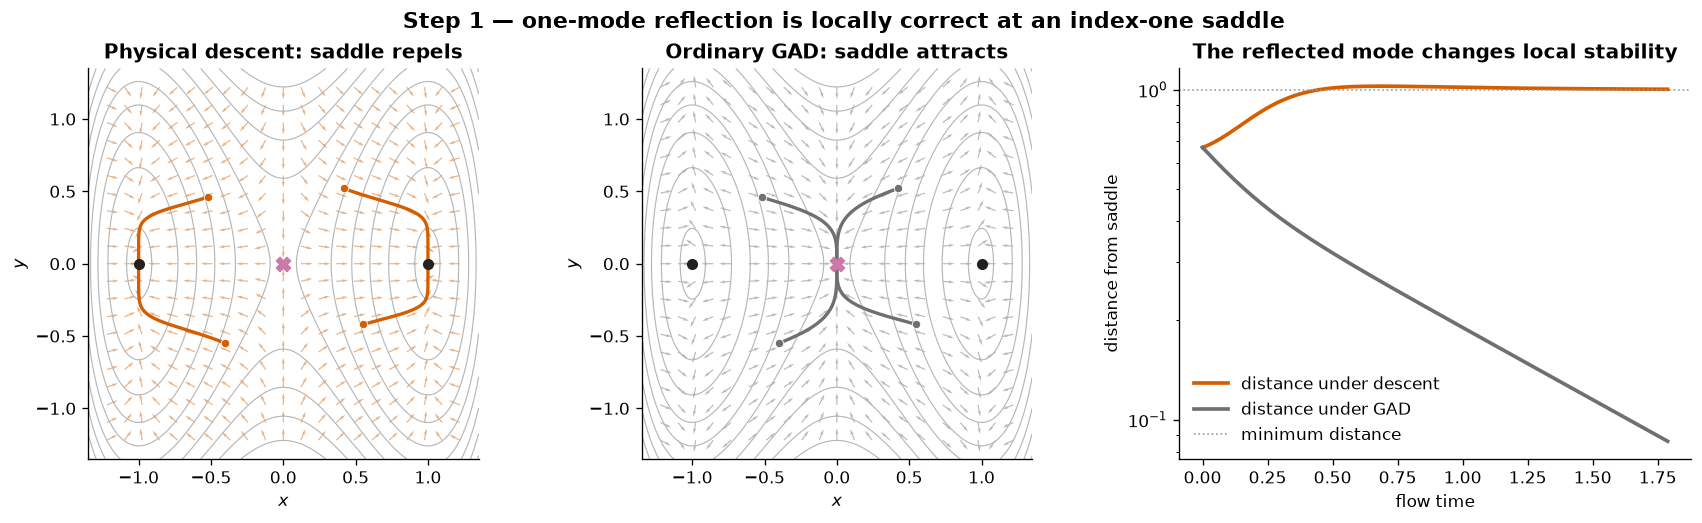

In [2]:
def E1(q):
    x, y = q
    return (x*x - 1.0)**2 + 0.5*y*y

def g1(q):
    x, y = q
    return np.array([4*x*(x*x - 1.0), y])

def H1(q):
    x, _ = q
    return np.diag([12*x*x - 4.0, 1.0])

def ordinary_field(q, grad, hess):
    lam, U = np.linalg.eigh(hess(q))
    c = U.T @ grad(q)
    c[0] *= -1.0
    return U @ (-c)

descent1 = lambda q: -g1(q)
gad1 = lambda q: ordinary_field(q, g1, H1)
starts1 = [(-.52,.46), (-.40,-.55), (.42,.52), (.55,-.42)]
grid1 = np.linspace(-1.35, 1.35, 260)
X1, Y1 = np.meshgrid(grid1, grid1)
Z1 = (X1*X1 - 1.0)**2 + 0.5*Y1*Y1

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.25), constrained_layout=True)
for ax, field, color, title in [
    (axes[0], descent1, COLORS['descent'], 'Physical descent: saddle repels'),
    (axes[1], gad1, COLORS['ordinary'], 'Ordinary GAD: saddle attracts'),
]:
    ax.contour(X1, Y1, Z1, levels=np.linspace(.03, 2.7, 15), colors='#B7B7B7', linewidths=.7)
    gx = np.linspace(-1.22, 1.22, 21); qx, qy = np.meshgrid(gx, gx)
    points = np.column_stack([qx.ravel(), qy.ravel()])
    arrows = normalized_arrows(field, points, .082)
    ax.quiver(points[:,0], points[:,1], arrows[:,0], arrows[:,1], angles='xy', scale_units='xy', scale=1,
              color=color, alpha=.48, width=.003, headwidth=2.6)
    for start in starts1:
        path = euler_trace(start, field, dt=.012, steps=260)
        ax.plot(path[:,0], path[:,1], color=color, lw=2.0)
        ax.scatter(*start, color=color, s=25, edgecolor='white', linewidth=.5, zorder=4)
    ax.scatter([0], [0], marker='X', s=70, color='#CC79A7', zorder=5)
    ax.scatter([-1,1], [0,0], s=32, color='#222222', zorder=5)
    finish_plane(ax, (-1.35,1.35), title)

t = np.arange(150) * .012
example_descent = euler_trace((.42,.52), descent1, .012, 149)
example_gad = euler_trace((.42,.52), gad1, .012, 149)
axes[2].semilogy(t, np.linalg.norm(example_descent, axis=1), color=COLORS['descent'], lw=2.2, label='distance under descent')
axes[2].semilogy(t, np.linalg.norm(example_gad, axis=1), color=COLORS['ordinary'], lw=2.2, label='distance under GAD')
axes[2].axhline(1, color='#999999', ls=':', lw=1, label='minimum distance')
axes[2].set(xlabel='flow time', ylabel='distance from saddle', title='The reflected mode changes local stability')
axes[2].legend(frameon=False)
fig.suptitle('Step 1 — one-mode reflection is locally correct at an index-one saddle', fontsize=13, fontweight='bold')
plt.show()

# 2. High-index starts have unreflected unstable directions

At a local index-two cap, take

$$V_2(x,y)=-2x^2-\tfrac12y^2,\qquad H=\operatorname{diag}(-4,-1).$$

Ordinary GAD reflects the lowest mode but leaves the second negative mode under physical descent: $\dot x=-4x$ while $\dot y=+y$. It is therefore a saddle flow, not an attractor, in this region. Descent lowers the energy in every gradient component and clears the high-index region before GAD is activated. The right panel gives the corresponding LJ7 evidence; the quadratic panels are only the local mechanism.

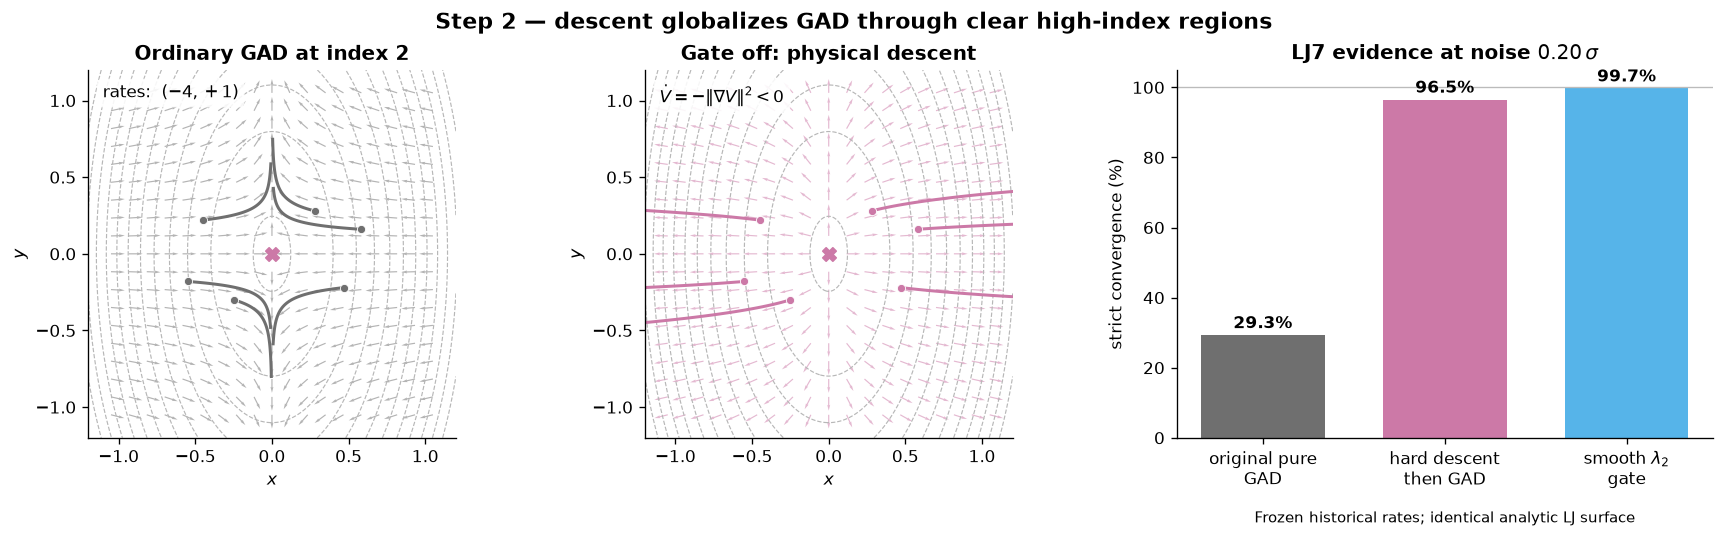

In [3]:
def E2(q):
    x, y = q
    return -2*x*x - 0.5*y*y

gad2 = lambda q: np.array([-4*q[0], q[1]])
descent2 = lambda q: np.array([4*q[0], q[1]])
starts2 = [(-.55,-.18), (-.45,.22), (-.25,-.30), (.28,.28), (.47,-.22), (.58,.16)]
g2 = np.linspace(-1.2,1.2,240); X2,Y2 = np.meshgrid(g2,g2); Z2 = -2*X2**2-.5*Y2**2

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.35), constrained_layout=True)
for ax, field, color, title in [
    (axes[0], gad2, COLORS['ordinary'], 'Ordinary GAD at index 2'),
    (axes[1], descent2, COLORS['hard'], 'Gate off: physical descent'),
]:
    ax.contour(X2,Y2,Z2,levels=np.linspace(-3.2,-.03,12),colors='#B7B7B7',linewidths=.7)
    gg=np.linspace(-1.05,1.05,19); qx,qy=np.meshgrid(gg,gg); points=np.column_stack([qx.ravel(),qy.ravel()])
    arrows=normalized_arrows(field,points,.09)
    ax.quiver(points[:,0],points[:,1],arrows[:,0],arrows[:,1],angles='xy',scale_units='xy',scale=1,
              color=color,alpha=.52,width=.0032,headwidth=2.5)
    for start in starts2:
        path=euler_trace(start,field,.018,55,stop_radius=1.35)
        ax.plot(path[:,0],path[:,1],color=color,lw=1.8)
        ax.scatter(*start,color=color,s=24,edgecolor='white',linewidth=.5,zorder=4)
    ax.scatter([0],[0],marker='X',s=65,color='#CC79A7',zorder=5)
    finish_plane(ax,(-1.2,1.2),title)
axes[0].text(.04,.96,'rates:  $(-4,+1)$',transform=axes[0].transAxes,va='top',
             bbox=dict(boxstyle='round,pad=.35',fc='white',ec='none',alpha=.88))
axes[1].text(.04,.96,r'$\dot V=-\|\nabla V\|^2<0$',transform=axes[1].transAxes,va='top',
             bbox=dict(boxstyle='round,pad=.35',fc='white',ec='none',alpha=.88))

labels=['original pure\nGAD','hard descent\nthen GAD','smooth $\lambda_2$\ngate']
rates=[29.3,96.5,99.7]
bars=axes[2].bar(labels,rates,color=[COLORS['ordinary'],COLORS['hard'],'#56B4E9'],width=.68)
axes[2].set(ylim=(0,105),ylabel='strict convergence (%)',title='LJ7 evidence at noise $0.20\,\sigma$')
axes[2].axhline(100,color='#BBBBBB',lw=.8)
for bar,value in zip(bars,rates):
    axes[2].text(bar.get_x()+bar.get_width()/2,value+2,f'{value:.1f}%',ha='center',fontweight='bold')
axes[2].text(.5,-.23,'Frozen historical rates; identical analytic LJ surface',transform=axes[2].transAxes,ha='center',fontsize=9)
fig.suptitle('Step 2 — descent globalizes GAD through clear high-index regions',fontsize=13,fontweight='bold')
plt.show()

# 3. Competitive GAD adds force activity to curvature

The smooth $\lambda_2$ gate sees only the normalized second eigenvalue, $z_2=\lambda_2/(\tau s_H)$. The competitive gate also asks whether the current physical gradient is concentrated in the soft direction:

$$w_2=\sigma(z_2),\qquad \chi=\frac{A_{\rm soft}}{A_{\rm soft}+A_{\rm extra}},\qquad w_{\rm comp}=w_2+(1-w_2)\chi.$$

Thus competition changes only the lower-right part of the mechanism map: a high-index curvature signature, but a strongly dominant soft-mode activity. It does not activate ascent when substantial force activity remains in additional negative directions.

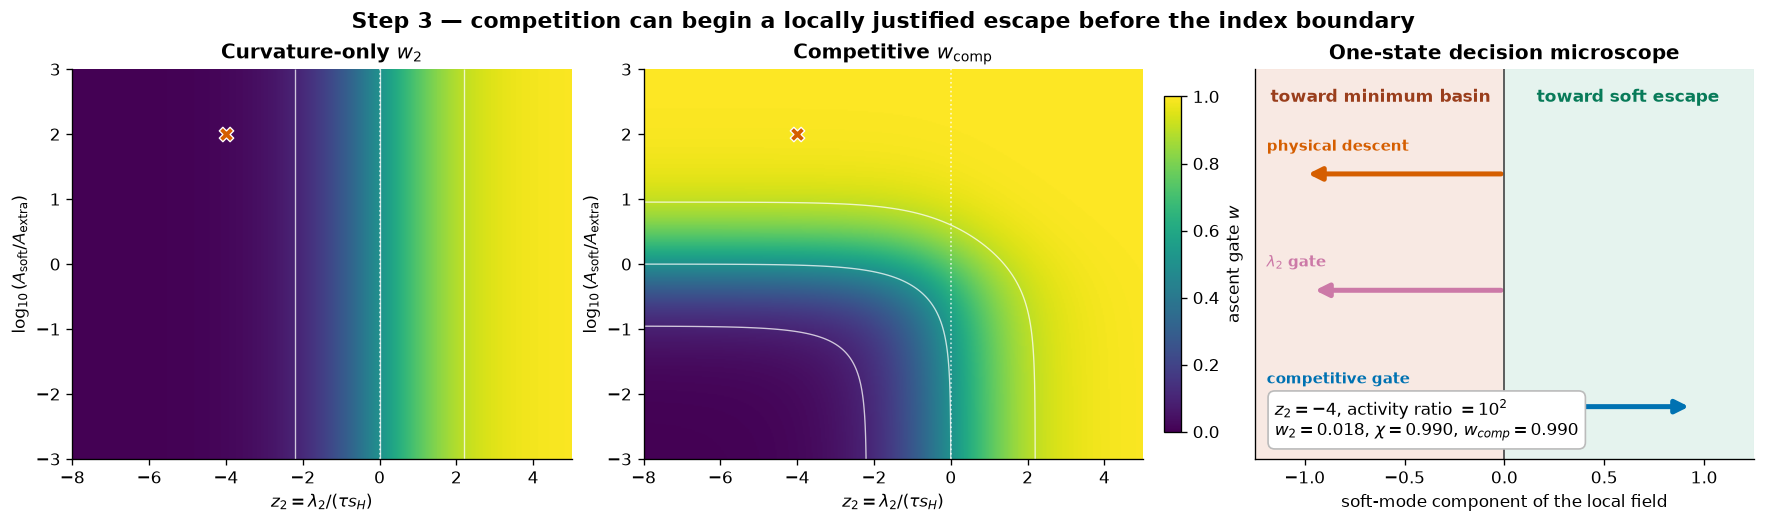

In [4]:
z2_axis=np.linspace(-8,5,360)
log_ratio=np.linspace(-3,3,300)
ZZ,LR=np.meshgrid(z2_axis,log_ratio)
ratio=10**LR
W2=sigmoid(ZZ)
CHI=ratio/(1+ratio)
WCOMP=W2+(1-W2)*CHI
selected=(-4.0,2.0)

fig,axes=plt.subplots(1,3,figsize=(14.6,4.25),constrained_layout=True)
for ax,data,title in [
    (axes[0],W2,'Curvature-only $w_2$'),
    (axes[1],WCOMP,r'Competitive $w_{\rm comp}$'),
]:
    im=ax.imshow(data,origin='lower',aspect='auto',extent=[z2_axis[0],z2_axis[-1],log_ratio[0],log_ratio[-1]],
                 vmin=0,vmax=1,cmap='viridis')
    ax.contour(ZZ,LR,data,levels=[.1,.5,.9],colors='white',linewidths=.8,alpha=.75)
    ax.scatter(*selected,marker='X',s=75,color='#D55E00',edgecolor='white',linewidth=.8,zorder=5)
    ax.axvline(0,color='white',ls=':',lw=1,alpha=.75)
    ax.set(xlabel=r'$z_2=\lambda_2/(\tau s_H)$',ylabel=r'$\log_{10}(A_{\rm soft}/A_{\rm extra})$',title=title)
cbar=fig.colorbar(im,ax=axes[:2],shrink=.86,pad=.02); cbar.set_label('ascent gate $w$')

z_sel,lr_sel=selected
w2_sel=float(sigmoid(z_sel)); chi_sel=10**lr_sel/(1+10**lr_sel); wc_sel=w2_sel+(1-w2_sel)*chi_sel
psoft=.98; csoft=1.0
directions={
    'physical descent': -csoft,
    '$\lambda_2$ gate': -(1-2*w2_sel*psoft)*csoft,
    'competitive gate': -(1-2*wc_sel*psoft)*csoft,
}
ypos=[2,1,0]; arrow_colors=[COLORS['descent'],COLORS['lambda2'],COLORS['competitive']]
axes[2].axvspan(-1.25,0,color='#F8E7E0',alpha=.9); axes[2].axvspan(0,1.25,color='#E3F2ED',alpha=.9)
axes[2].axvline(0,color='#444444',lw=1)
for (label,direction),y,color in zip(directions.items(),ypos,arrow_colors):
    axes[2].add_patch(FancyArrowPatch((0,y),(direction,y),arrowstyle='-|>',mutation_scale=16,lw=3,color=color))
    axes[2].text(-1.19,y+.20,label,color=color,fontweight='bold',fontsize=9)
axes[2].text(-.62,2.62,'toward minimum basin',ha='center',color='#9A3E1C',fontweight='bold')
axes[2].text(.62,2.62,'toward soft escape',ha='center',color='#087B59',fontweight='bold')
axes[2].set(xlim=(-1.25,1.25),ylim=(-.45,2.9),yticks=[],xlabel='soft-mode component of the local field',
            title='One-state decision microscope')
axes[2].text(.04,.06,fr'$z_2={z_sel:.0f}$, activity ratio $=10^{{{lr_sel:.0f}}}$'+'\n'+
             fr'$w_2={w2_sel:.3f}$, $\chi={chi_sel:.3f}$, $w_{{comp}}={wc_sel:.3f}$',
             transform=axes[2].transAxes,bbox=dict(boxstyle='round,pad=.4',fc='white',ec='#BBBBBB'))
fig.suptitle('Step 3 — competition can begin a locally justified escape before the index boundary',fontsize=13,fontweight='bold')
plt.show()

The orange cross marks the same state in both maps. The curvature-only gate remains almost pure descent because $z_2=-4$. Competitive GAD sees a 100:1 activity ratio and makes the opposite soft-mode decision. This is the exact additional effect of step 3; it is not merely a smoother $\lambda_2$ switch.

A global potential can obscure this comparison because any continuous route from index two to index zero crosses an index-one boundary. Minimum capture in the molecular runs is a finite-step, rotating-mode phenomenon. The local state-space map therefore makes the claim more directly than a contrived 2D terminal trajectory.

# 4. Relative soft-subspace reflection prevents degeneracy dilution

Use an isotropic central basin surrounded by four discrete index-one saddles:

$$s=x^2+y^2,$$
$$V_4=\tfrac12s-\tfrac34s^2+\tfrac16s^3+\epsilon(x^4-6x^2y^2+y^4),\qquad \epsilon=0.03.$$

Near the central minimum, $H\approx I$ and $p_1\approx p_2\approx1/2$. With an active gate, normalized-density reflection gives $1-2wp_i\approx0$: it nearly cancels the local field. CS²-GAD instead uses $\widetilde p_i=p_i/\max_jp_j$, giving unit weight to the tied lowest subspace and a full, rotation-invariant reversal. The start must be slightly displaced because every force-proportional pointwise method has zero step at an exact stationary minimum.

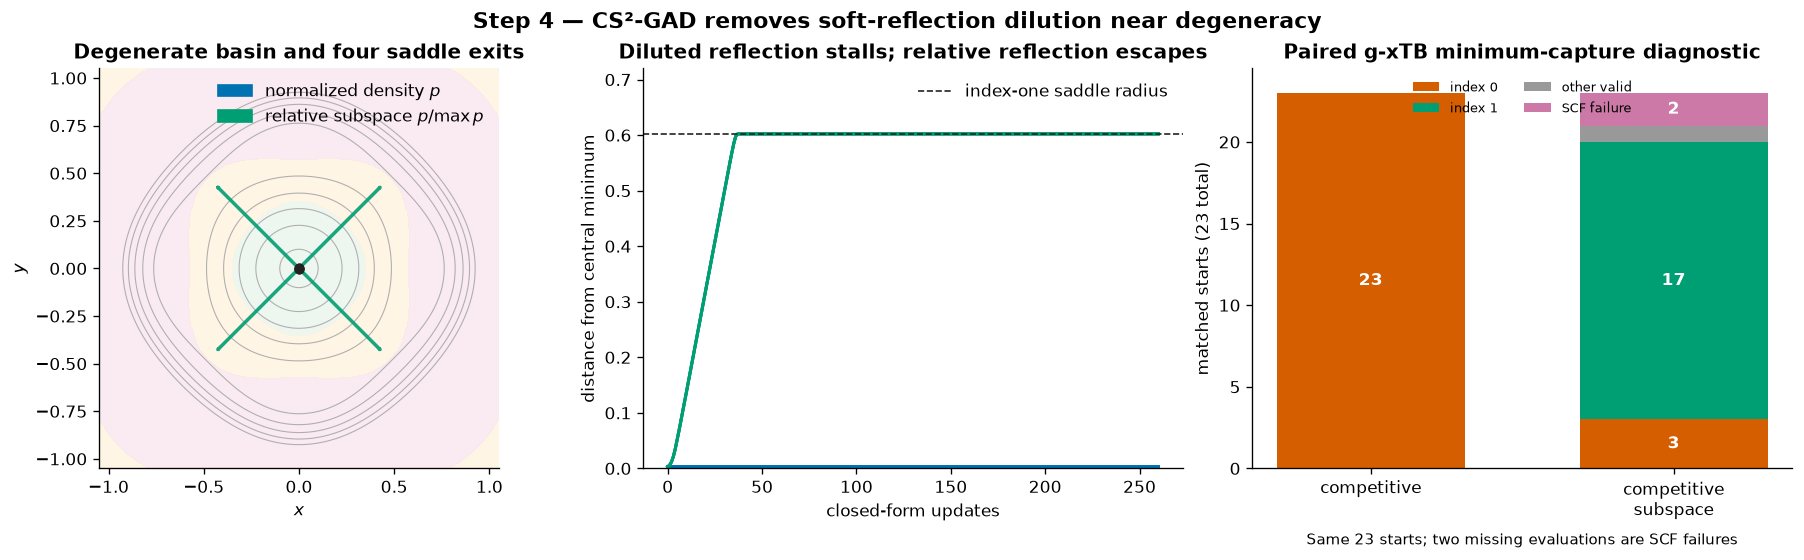

In [5]:
EPS4=.03
def E4(q):
    x,y=q; s=x*x+y*y
    return .5*s-.75*s*s+s**3/6 + EPS4*(x**4-6*x*x*y*y+y**4)

def g4(q):
    x,y=q; s=x*x+y*y
    radial=(1-3*s+s*s)*np.array([x,y])
    anis=EPS4*np.array([4*x**3-12*x*y*y,4*y**3-12*x*x*y])
    return radial+anis

def H4(q):
    x,y=q; s=x*x+y*y; v=np.array([x,y])
    H=(1-3*s+s*s)*np.eye(2)+4*(-1.5+s)*np.outer(v,v)
    H+=EPS4*np.array([[12*x*x-12*y*y,-24*x*y],[-24*x*y,12*y*y-12*x*x]])
    return H

def soft_step4(q, relative=False, tau=.18, R=.018):
    lam,U=np.linalg.eigh(H4(q)); c=U.T@g4(q); sH=max(np.sqrt(np.mean(lam**2)),1e-12)
    z=lam/(tau*sH); p=np.exp(-z-np.max(-z)); p/=p.sum()
    neg=sigmoid(-z); w2=sigmoid(z[1])
    Asoft=np.sum(p*c*c); Aextra=np.sum(neg*(1-p)**2*c*c)
    chi=Asoft/(Asoft+Aextra) if Asoft+Aextra>0 else 0.0
    w=w2+(1-w2)*chi; r=p/p.max() if relative else p
    b=(1-2*w*r)*c; mu=np.linalg.norm(b)/R if np.linalg.norm(b)>0 else 0.0
    step=U@(-b/np.sqrt(lam*lam+mu*mu))
    return step,dict(lam=lam,p=p,w=w,r=r,multiplier=1-2*w*r)

def trace4(start,relative,steps=260):
    path=[np.asarray(start,dtype=float)]; diagnostics=[]
    for _ in range(steps):
        dq,diag=soft_step4(path[-1],relative=relative); diagnostics.append(diag)
        path.append(path[-1]+dq)
    return np.asarray(path),diagnostics

angles=np.pi/4+np.arange(4)*np.pi/2
starts4=[.003*np.array([np.cos(a),np.sin(a)]) for a in angles]
density_paths=[trace4(s,False)[0] for s in starts4]
relative_paths=[trace4(s,True)[0] for s in starts4]

grid4=np.linspace(-1.05,1.05,360); X4,Y4=np.meshgrid(grid4,grid4)
S4=X4*X4+Y4*Y4
Z4=.5*S4-.75*S4**2+S4**3/6+EPS4*(X4**4-6*X4*X4*Y4*Y4+Y4**4)
idx4=np.empty_like(X4,dtype=int)
for ij in np.ndindex(X4.shape):
    idx4[ij]=np.sum(np.linalg.eigvalsh(H4((X4[ij],Y4[ij])))<0)

fig,axes=plt.subplots(1,3,figsize=(15.0,4.55),constrained_layout=True)
ax=axes[0]
ax.contourf(X4,Y4,idx4,levels=[-.5,.5,1.5,2.5],cmap=INDEX_CMAP,alpha=.78)
ax.contour(X4,Y4,Z4,levels=np.linspace(.005,.23,13),colors='#AFAFAF',linewidths=.65)
for path in density_paths:
    ax.plot(path[:,0],path[:,1],color=COLORS['competitive'],lw=2.1,alpha=.9)
for path in relative_paths:
    ax.plot(path[:,0],path[:,1],color=COLORS['subspace'],lw=2.1,alpha=.9)
ax.scatter(*np.asarray(starts4).T,s=25,color='#222222',zorder=5,label='slightly displaced starts')
finish_plane(ax,(-1.05,1.05),'Degenerate basin and four saddle exits')
ax.legend(handles=[Patch(color=COLORS['competitive'],label='normalized density $p$'),
                   Patch(color=COLORS['subspace'],label=r'relative subspace $p/\max p$')],frameon=False,loc='upper right')

r_density=[np.linalg.norm(p,axis=1) for p in density_paths]
r_relative=[np.linalg.norm(p,axis=1) for p in relative_paths]
for r in r_density:
    axes[1].plot(r,color=COLORS['competitive'],lw=1.8,alpha=.85)
for r in r_relative:
    axes[1].plot(r,color=COLORS['subspace'],lw=1.8,alpha=.85)
inner_s=(3+4*EPS4-np.sqrt((3+4*EPS4)**2-4))/2
axes[1].axhline(np.sqrt(inner_s),color='#222222',ls='--',lw=1,label='index-one saddle radius')
axes[1].set(xlabel='closed-form updates',ylabel='distance from central minimum',ylim=(0,.72),
            title='Diluted reflection stalls; relative reflection escapes')
axes[1].legend(frameon=False)

categories=['index 0','index 1','other valid','SCF failure']
baseline=np.array([23,0,0,0]); refined=np.array([3,17,1,2])
cat_colors=['#D55E00','#009E73','#999999','#CC79A7']
bottom=np.zeros(2)
for i,(cat,color) in enumerate(zip(categories,cat_colors)):
    vals=np.array([baseline[i],refined[i]])
    axes[2].bar(['competitive','competitive\nsubspace'],vals,bottom=bottom,color=color,label=cat,width=.62)
    for j,val in enumerate(vals):
        if val>=2: axes[2].text(j,bottom[j]+val/2,str(val),ha='center',va='center',color='white',fontweight='bold')
    bottom+=vals
axes[2].set(ylim=(0,24.5),ylabel='matched starts (23 total)',title='Paired g-xTB minimum-capture diagnostic')
axes[2].legend(frameon=False,ncol=2,loc='upper center',fontsize=8)
axes[2].text(.5,-.19,'Same 23 starts; two missing evaluations are SCF failures',transform=axes[2].transAxes,ha='center',fontsize=9)
fig.suptitle('Step 4 — CS²-GAD removes soft-reflection dilution near degeneracy',fontsize=13,fontweight='bold')
plt.show()

## What the degeneracy experiment does—and does not—claim

The relevant failure is **reflection dilution**, not merely a small eigenvalue. A tilted sombrero has a soft tangent mode but normally a large gap to its radial mode; that is not the degeneracy addressed here. In the constructed basin, two comparably soft modes receive $p_i\approx1/2$, so the intermediate normalized rule nearly cancels descent instead of producing ascent. Relative weights act on the low-curvature subspace without choosing an arbitrary eigenvector.

The toy deliberately shows the local escape mechanism. The stacked bar is the evidence that this mechanism mattered on matched molecular starts: 20 of 23 original minimum captures were prevented, while two refined calculations failed in g-xTB rather than reaching optimizer terminals.

# Takeaway

<div style="padding: 0.9em 1.1em; border-left: 5px solid #009E73; background: #F3FBF7">
<b>The four additions solve different local problems.</b> Ordinary GAD stabilizes an index-one saddle. The $\lambda_2$ gate prevents unreflected high-index modes from dominating entry. Competition uses current force activity to begin a justified soft escape before curvature alone permits it. Relative soft-subspace reflection prevents that escape from being diluted when several lowest modes are comparable.
</div>

These panels should be read alongside the compact [`gad_evolution_four_wells.ipynb`](gad_evolution_four_wells.ipynb) overview and the complete derivation in [`POINTWISE_INTRINSIC_GAD.md`](../docs/POINTWISE_INTRINSIC_GAD.md).